In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Without Cross-Validation": [
        0.5060,
        0.7555,
        0.9148,
        0.7224,
        0.8073,
        0.8651
    ],
    "With 5-Fold Cross-Validation": [
        0.5062,
        0.7545,
        0.9144,
        0.7214,
        0.8065,
        0.8658
    ]
})

display(comparison_df)

,Metric,Without Cross-Validation,With 5-Fold Cross-Validation
0,Test Loss,0.5060,0.5062
1,Accuracy,0.7555,0.7545
2,Precision,0.9148,0.9144
3,Recall,0.7224,0.7214
4,F1-score,0.8073,0.8065
5,ROC-AUC,0.8651,0.8658


In [11]:
epoch_comparison_df = pd.DataFrame({
    "Experiment": [
        "Without Cross-Validation",
        "With 5-Fold Cross-Validation"
    ],
    "Best Epochs": [
        "6",
        "3, 6, 9, 8, 9"
    ],
    "Mean Best Epoch": [
        6.0,
        np.mean([3, 6, 9, 8, 9])
    ],
    "Epochs Actually Trained": [
        "11",
        "8, 11, 14, 13, 14"
    ],
    "Mean Epochs Trained": [
        11.0,
        np.mean([8, 11, 14, 13, 14])
    ]
})

display(epoch_comparison_df)

,Experiment,Best Epochs,Mean Best Epoch,Epochs Actually Trained,Mean Epochs Trained
0,Without Cross-Validation,6,6.0,11,11.0
1,With 5-Fold Cross-Validation,"3, 6, 9, 8, 9",7.0,"8, 11, 14, 13, 14",12.0


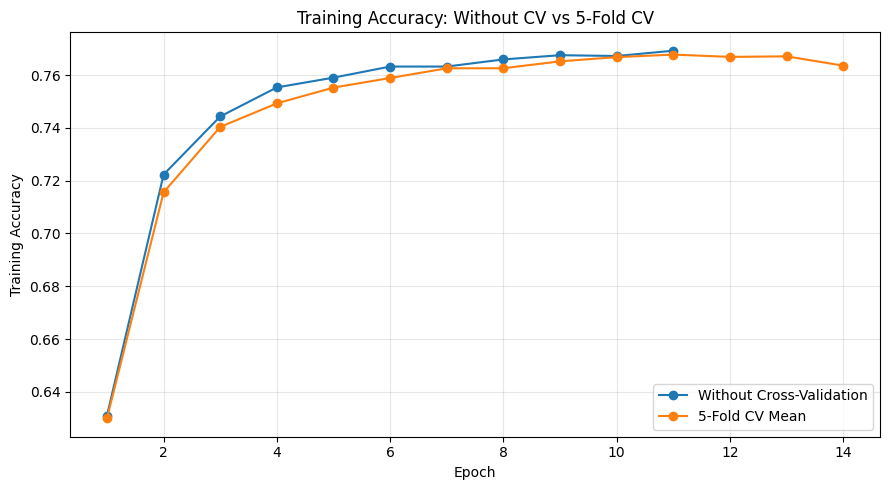

In [12]:
normal_training_accuracy = [
    0.6310, 0.7223, 0.7443, 0.7553, 0.7590,
    0.7632, 0.7632, 0.7659, 0.7675, 0.7672,
    0.7692
]

cv_training_accuracy = {
    1: [0.6298, 0.7193, 0.7439, 0.7519, 0.7601, 0.7616, 0.7654, 0.7629],
    2: [0.6344, 0.7173, 0.7451, 0.7525, 0.7568, 0.7618, 0.7662, 0.7640, 0.7691, 0.7677, 0.7695],
    3: [0.6378, 0.7177, 0.7413, 0.7470, 0.7540, 0.7591, 0.7607, 0.7596, 0.7611, 0.7628, 0.7621, 0.7643, 0.7614, 0.7596],
    4: [0.6147, 0.7099, 0.7366, 0.7458, 0.7559, 0.7586, 0.7628, 0.7677, 0.7690, 0.7696, 0.7707, 0.7712, 0.7722],
    5: [0.6331, 0.7136, 0.7348, 0.7491, 0.7494, 0.7532, 0.7576, 0.7586, 0.7615, 0.7670, 0.7686, 0.7651, 0.7676, 0.7675]
}

cv_accuracy_df = pd.DataFrame(
    {
        f"Fold {fold}": pd.Series(values)
        for fold, values in cv_training_accuracy.items()
    }
)

cv_mean_training_accuracy = cv_accuracy_df.mean(
    axis=1,
    skipna=True
)

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(normal_training_accuracy) + 1),
    normal_training_accuracy,
    marker="o",
    label="Without Cross-Validation"
)

plt.plot(
    range(1, len(cv_mean_training_accuracy) + 1),
    cv_mean_training_accuracy,
    marker="o",
    label="5-Fold CV Mean"
)

plt.title("Training Accuracy: Without CV vs 5-Fold CV")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

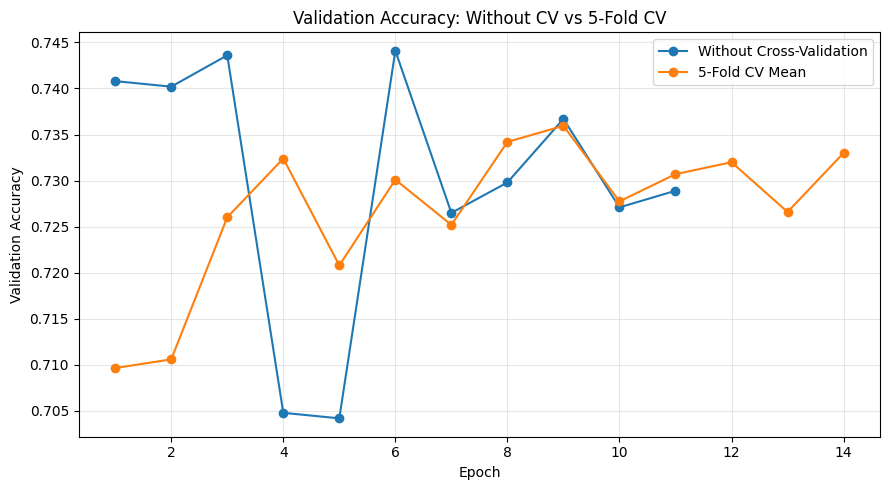

In [13]:
normal_validation_accuracy = [
    0.7408, 0.7402, 0.7436, 0.7048, 0.7042,
    0.7441, 0.7265, 0.7298, 0.7367, 0.7271,
    0.7289
]

cv_validation_accuracy = {
    1: [0.7000, 0.7257, 0.7551, 0.7443, 0.7374, 0.7404, 0.7448, 0.7336],
    2: [0.7243, 0.7400, 0.7352, 0.7303, 0.6896, 0.7444, 0.7227, 0.7369, 0.7267, 0.7344, 0.7320],
    3: [0.7110, 0.6846, 0.7021, 0.7368, 0.7152, 0.7168, 0.7237, 0.7311, 0.7380, 0.7337, 0.7360, 0.7353, 0.7320, 0.7298],
    4: [0.6873, 0.6869, 0.7294, 0.7301, 0.7344, 0.7167, 0.7151, 0.7326, 0.7275, 0.7139, 0.7283, 0.7166, 0.7199],
    5: [0.7257, 0.7158, 0.7083, 0.7205, 0.7274, 0.7322, 0.7197, 0.7368, 0.7516, 0.7290, 0.7265, 0.7441, 0.7279, 0.7362]
}

cv_validation_df = pd.DataFrame({
    f"Fold {fold}": pd.Series(values)
    for fold, values in cv_validation_accuracy.items()
})

cv_mean_validation_accuracy = cv_validation_df.mean(
    axis=1,
    skipna=True
)

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(normal_validation_accuracy) + 1),
    normal_validation_accuracy,
    marker="o",
    label="Without Cross-Validation"
)

plt.plot(
    range(1, len(cv_mean_validation_accuracy) + 1),
    cv_mean_validation_accuracy,
    marker="o",
    label="5-Fold CV Mean"
)

plt.title("Validation Accuracy: Without CV vs 5-Fold CV")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

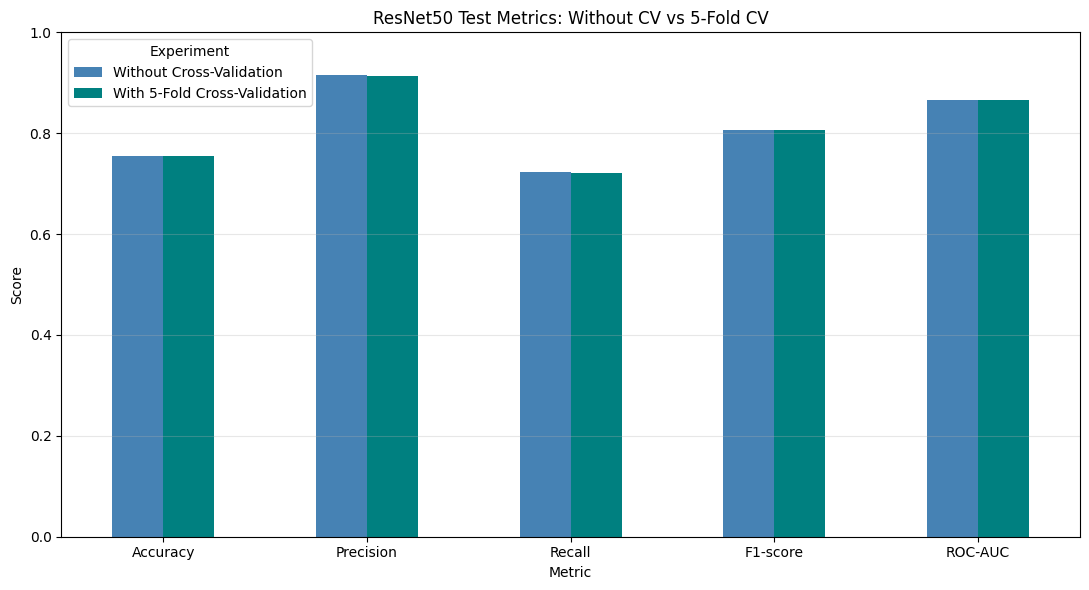

In [14]:
score_df = comparison_df[
    comparison_df["Metric"] != "Test Loss"
].set_index("Metric")

score_df.plot(
    kind="bar",
    figsize=(11, 6),
    color=["steelblue", "teal"]
)

plt.title("ResNet50 Test Metrics: Without CV vs 5-Fold CV")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Experiment")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

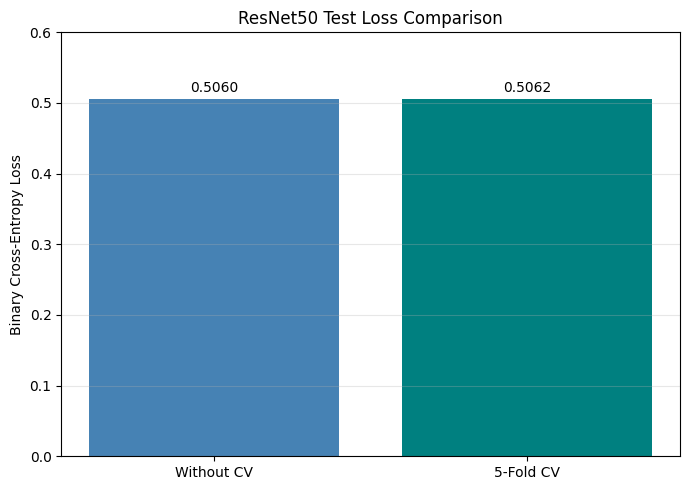

In [15]:
loss_values = comparison_df.loc[
    comparison_df["Metric"] == "Test Loss",
    [
        "Without Cross-Validation",
        "With 5-Fold Cross-Validation"
    ]
].iloc[0]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Without CV", "5-Fold CV"],
    loss_values,
    color=["steelblue", "teal"]
)

plt.title("ResNet50 Test Loss Comparison")
plt.ylabel("Binary Cross-Entropy Loss")
plt.ylim(0, 0.6)

for bar, value in zip(bars, loss_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()